In [1]:
# ⚠️ Run this cell FIRST. After it completes, go to Runtime → Restart runtime.
# Then run all cells from Block 1 onwards.

!pip install transformers==4.40.0 datasets accelerate sentencepiece protobuf
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud openpyxl nlpaug
!pip install imbalanced-learn

# The following lines are commented out as they cause an error if no GPU is available.
# The notebook will automatically use CPU if a GPU is not detected.
# import subprocess
# result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
!pip install huggingface_hub
!pip install onnx onnxruntime optimum onnxscript
# print(result.stdout if result.returncode == 0 else "⚠️ No GPU found — go to Runtime → Change runtime type → T4 GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 45.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    get_cosine_schedule_with_warmup
)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME   = "xlm-roberta-base"
MAX_LEN      = 256          # covers all entries (max ~417 approx tokens, but XLM-R tokenizes differently)
BATCH_SIZE   = 16           # safe for T4 (16GB). Lower to 8 if OOM.
EPOCHS       = 6
LR           = 1.5e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.05         # v6: mild L2 increase
LABEL_SMOOTH = 0.13         # v6: caps train overconfidence on easy augmented samples
NUM_CLASSES  = 5
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTIONS = ['angry', 'anxious', 'happy', 'neutral', 'sad']  # alphabetical = LabelEncoder order
EMOTION_COLORS = {
    'happy':   '#FFD700',
    'sad':     '#5B9BD5',
    'angry':   '#E74C3C',
    'anxious': '#9B59B6',
    'neutral': '#95A5A6'
}

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Model: {MODEL_NAME}")
print("✅ Config loaded.")




Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Model: xlm-roberta-base
✅ Config loaded.


In [3]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f"Shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nLanguage distribution:\n{df['language'].value_counts()}")
print(f"\nLabel × Language:\n{pd.crosstab(df['label'], df['language'])}")

# Word count stats per label
df['word_count'] = df['text'].str.split().str.len()
df['sent_count']  = df['text'].str.count(r'[.!?]+')
print(f"\nWord count per label:")
print(df.groupby('label')['word_count'].describe().round(1))

# ── Neutral class deep-dive ───────────────────────────────────────────────────
emotion_words = ['happy','joy','sad','angry','anxious','worried','excited',
                 'upset','frustrated','nervous','fear','afraid','scared']
neutral_df = df[df['label']=='neutral'].copy()
neutral_df['leakage_count'] = neutral_df['text'].apply(
    lambda x: sum(1 for w in emotion_words if w.lower() in x.lower())
)
print(f"\n⚠️  Neutral entries with emotional word leakage:")
print(neutral_df['leakage_count'].value_counts().sort_index())
print(f"\nNeutral avg sentences: {df[df['label']=='neutral']['sent_count'].mean():.2f}")
print(f"Other avg sentences:   {df[df['label']!='neutral']['sent_count'].mean():.2f}")
print("\n✅ Dataset loaded and analyzed.")

Saving Final_Dataset.xlsx to Final_Dataset.xlsx
Shape: (1593, 3)

Label distribution:
label
neutral    334
angry      330
sad        330
happy      300
anxious    299
Name: count, dtype: int64

Language distribution:
language
english     589
taglish     515
filipino    488
neutral       1
Name: count, dtype: int64

Label × Language:
language  english  filipino  neutral  taglish
label                                        
angry         130        96        0      104
anxious        99       100        0      100
happy         100       100        0      100
neutral       130        99        1      104
sad           130        93        0      107

Word count per label:
         count   mean   std    min    25%    50%    75%    max
label                                                         
angry    330.0  173.0  38.4   49.0  163.0  182.0  195.0  236.0
anxious  299.0  182.9  40.7   76.0  168.0  187.0  204.0  309.0
happy    300.0  163.4  31.3   61.0  146.0  167.0  180.2  246.0
neutr

In [4]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ================================
# CONFIG
# ================================
TEXT_COL = 'text'   # change if needed
NGRAM_RANGE = (3, 5)
SIM_THRESHOLD = 0.75

# ================================
# CLEAN TEXT
# ================================
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[^a-zA-Z0-9\s]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['clean'] = df[TEXT_COL].apply(clean_text)

# ================================
# 1. SENTENCE START PATTERNS
# ================================
def get_starts(text):
    sentences = re.split(r'[.!?]', text)
    starts = []
    for s in sentences:
        words = s.strip().split()
        if len(words) >= 3:
            starts.append(' '.join(words[:3]))
    return starts

all_starts = []
for t in df['clean']:
    all_starts.extend(get_starts(t))

start_counts = Counter(all_starts)

print("\n🔁 TOP SENTENCE STARTS (possible templates):")
for s, c in start_counts.most_common(15):
    print(f"{s:30s} → {c}")

# ================================
# 2. REPEATED PHRASES (N-GRAMS)
# ================================
vectorizer = CountVectorizer(ngram_range=NGRAM_RANGE, min_df=3)
X = vectorizer.fit_transform(df['clean'])

ngrams = vectorizer.get_feature_names_out()
counts = np.asarray(X.sum(axis=0)).flatten()

ngram_df = pd.DataFrame({
    'phrase': ngrams,
    'count': counts
}).sort_values(by='count', ascending=False)

print("\n🔁 TOP REPEATED PHRASES:")
print(ngram_df.head(15))

# ================================
# 3. STRUCTURE SIMILARITY
# ================================
def sentence_lengths(text):
    sentences = re.split(r'[.!?]', text)
    return [len(s.split()) for s in sentences if len(s.strip()) > 0]

df['structure'] = df['clean'].apply(sentence_lengths)

MAX_LEN = 10
def pad(x):
    return (x + [0]*MAX_LEN)[:MAX_LEN]

struct_matrix = np.array(df['structure'].apply(pad).tolist())
struct_sim = cosine_similarity(struct_matrix)

struct_duplicates = []
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if struct_sim[i][j] > 0.9:
            struct_duplicates.append((i, j))

print(f"\n🔁 STRUCTURAL DUPLICATES FOUND: {len(struct_duplicates)}")

# ================================
# 4. FULL TEXT SIMILARITY
# ================================
tfidf = CountVectorizer(max_features=5000)
X_text = tfidf.fit_transform(df['clean'])
sim_matrix = cosine_similarity(X_text)

duplicates = []
for i in range(len(df)):
    for j in range(i+1, len(df)):
        if sim_matrix[i][j] > SIM_THRESHOLD:
            duplicates.append((i, j, sim_matrix[i][j]))

print(f"\n🚨 POTENTIAL TEMPLATE DUPLICATES: {len(duplicates)}")

# show examples
print("\n🔍 SAMPLE DUPLICATES:")
for i, j, score in duplicates[:5]:
    print(f"\nPair ({i}, {j}) — similarity: {score:.2f}")
    print("A:", df.iloc[i][TEXT_COL][:120])
    print("B:", df.iloc[j][TEXT_COL][:120])


🔁 TOP SENTENCE STARTS (possible templates):
bakit ba laging                → 20
i cant believe                 → 16
i am so                        → 16
i went to                      → 11
hindi ako makatulog            → 10
pumunta ako sa                 → 9
natatakot ako na               → 8
nagluto ako ng                 → 8
kanina pa ako                  → 7
i have to                      → 7
i cant stop                    → 7
i have this                    → 7
nagayos ako ng                 → 7
stop telling me                → 6
may nakita akong               → 6

🔁 TOP REPEATED PHRASES:
                                        phrase  count
6699               like minor movements simple    215
6698                      like minor movements    215
13539               were also routine elements    215
13538                        were also routine    215
451                      also routine elements    215
453         also routine elements present like    215
9812                  

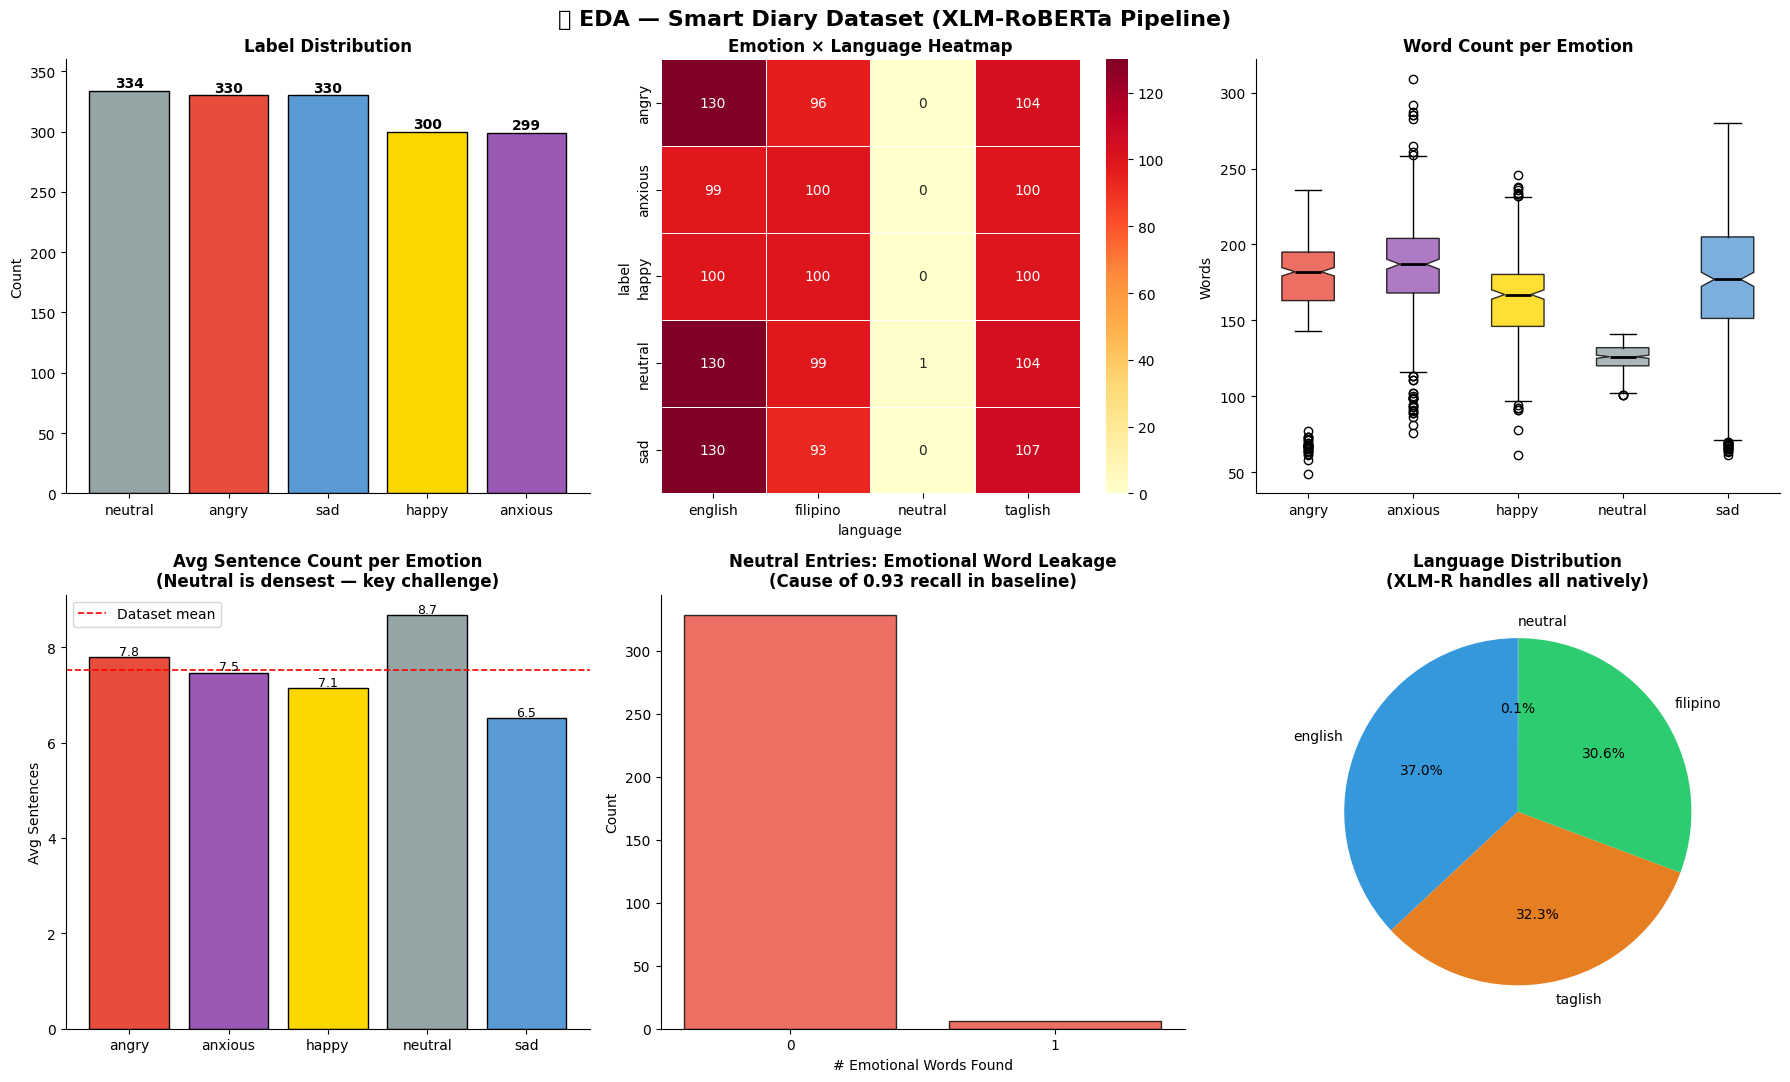

✅ EDA complete.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("📊 EDA — Smart Diary Dataset (XLM-RoBERTa Pipeline)", fontsize=16, fontweight='bold')

# 1. Label distribution
ax = axes[0, 0]
counts = df['label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[EMOTION_COLORS[e] for e in counts.index], edgecolor='black')
ax.set_title("Label Distribution", fontweight='bold')
ax.set_ylabel("Count"); ax.set_ylim(0, 360)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, str(val), ha='center', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# 2. Language × Label heatmap
ax = axes[0, 1]
cross = pd.crosstab(df['label'], df['language'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title("Emotion × Language Heatmap", fontweight='bold')

# 3. Word count box plot
ax = axes[0, 2]
data_bp = [df[df['label']==e]['word_count'].values for e in EMOTIONS]
bp = ax.boxplot(data_bp, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, em in zip(bp['boxes'], EMOTIONS):
    patch.set_facecolor(EMOTION_COLORS[em]); patch.set_alpha(0.8)
ax.set_xticks(range(1, 6)); ax.set_xticklabels(EMOTIONS)
ax.set_title("Word Count per Emotion", fontweight='bold'); ax.set_ylabel("Words")
ax.spines[['top','right']].set_visible(False)

# 4. Sentence count per emotion
ax = axes[1, 0]
sent_means = df.groupby('label')['sent_count'].mean().reindex(EMOTIONS)
bars2 = ax.bar(sent_means.index, sent_means.values,
               color=[EMOTION_COLORS[e] for e in EMOTIONS], edgecolor='black')
ax.set_title("Avg Sentence Count per Emotion\n(Neutral is densest — key challenge)", fontweight='bold')
ax.set_ylabel("Avg Sentences")
ax.axhline(sent_means.mean(), color='red', linestyle='--', linewidth=1.2, label='Dataset mean')
ax.legend(); ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, sent_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.1f}', ha='center', fontsize=9)

# 5. Neutral leakage analysis
ax = axes[1, 1]
leak_counts = neutral_df['leakage_count'].value_counts().sort_index()
ax.bar(leak_counts.index.astype(str), leak_counts.values,
       color='#E74C3C', edgecolor='black', alpha=0.8)
ax.set_title("Neutral Entries: Emotional Word Leakage\n(Cause of 0.93 recall in baseline)", fontweight='bold')
ax.set_xlabel("# Emotional Words Found"); ax.set_ylabel("Count")
ax.spines[['top','right']].set_visible(False)

# 6. Language distribution pie
ax = axes[1, 2]
lang_counts = df['language'].value_counts()
ax.pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%',
       colors=['#3498DB','#E67E22','#2ECC71'], startangle=90)
ax.set_title("Language Distribution\n(XLM-R handles all natively)", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_xlmr.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA complete.")

In [6]:
# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['text'].values
y = df['label_enc'].values
lang = df['language'].values

# 70% train | 10% val | 20% test — stratified
X_train, X_test, y_train, y_test, lang_train, lang_test = train_test_split(
    X, y, lang, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val, lang_train, lang_val = train_test_split(
    X_train, y_train, lang_train, test_size=0.125, random_state=SEED, stratify=y_train
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"\nTrain distribution:\n{pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()}")
print(f"\nVal distribution:\n{pd.Series(y_val).map(dict(enumerate(le.classes_))).value_counts()}")
print(f"\nTest distribution:\n{pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts()}")

# Class weights (addresses neutral softly — it's balanced but semantically harder)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"\nClass weights: {dict(zip(le.classes_, class_weights.round(3)))}")

# ── Boost weights for the hard-to-separate classes ───────────────────────────
# Root-cause analysis: angry/sad are confused with anxious due to overlapping
# vocabulary ('pressure', 'constant', 'tension', 'heavy'). We boost angry, sad,
# neutral so the model is penalised harder when it gets these wrong.
# Anxious is NOT boosted — it was already over-predicted; boosting would worsen it.
HARD_CLASSES     = ['angry', 'sad', 'neutral', 'happy']  # added happy — needs sharper boundary from sad
HARD_BOOST       = 1.1   # stronger penalty — these are the misclassified classes
for cls_name in HARD_CLASSES:
    cls_idx = le.transform([cls_name])[0]
    class_weights[cls_idx] *= HARD_BOOST
# Re-normalise so mean weight stays ~1.0 (keeps learning rate effective)
class_weights = class_weights / class_weights.mean()
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Boosted class weights: {dict(zip(le.classes_, class_weights.round(3)))}")
print("✅ Hard-class weight boosting applied.")
print("✅ Split complete.")



Label encoding: {'angry': np.int64(0), 'anxious': np.int64(1), 'happy': np.int64(2), 'neutral': np.int64(3), 'sad': np.int64(4)}

Train: 1114 | Val: 160 | Test: 319

Train distribution:
neutral    233
angry      231
sad        231
happy      210
anxious    209
Name: count, dtype: int64

Val distribution:
neutral    34
sad        33
angry      33
anxious    30
happy      30
Name: count, dtype: int64

Test distribution:
neutral    67
angry      66
sad        66
anxious    60
happy      60
Name: count, dtype: int64

Class weights: {'angry': np.float64(0.965), 'anxious': np.float64(1.066), 'happy': np.float64(1.061), 'neutral': np.float64(0.956), 'sad': np.float64(0.965)}
Boosted class weights: {'angry': np.float64(0.981), 'anxious': np.float64(0.986), 'happy': np.float64(1.079), 'neutral': np.float64(0.973), 'sad': np.float64(0.981)}
✅ Hard-class weight boosting applied.
✅ Split complete.


In [7]:
# ── Strategy: Targeted augmentation for the confused trio (angry / sad / neutral) ─
# angry → predicted as anxious: somatic/suppressed anger shares vocabulary with anxious
# sad → predicted as anxious: introspective sadness overlaps with anxious signals
# neutral → predicted as happy: reflective neutral lacks factual anchors
# Fix: augment all problem classes so the model sees more surface-form variation

import re

def word_dropout_augment(text, drop_rate=0.1, seed=None):
    """Randomly drop non-essential words to create robust variants."""
    if seed is not None:
        random.seed(seed)
    words = text.split()
    # Never drop first or last word (keep context anchors)
    keep = [True] + [random.random() > drop_rate for _ in words[1:-1]] + [True]
    result = [w for w, k in zip(words, keep) if k]
    return ' '.join(result)

def random_swap_augment(text, n_swaps=2):
    """Randomly swap adjacent word pairs — preserves meaning, changes surface form."""
    words = text.split()
    if len(words) < 4:
        return text
    for _ in range(n_swaps):
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join(words)

def random_insert_augment(text, insert_rate=0.05):
    """Randomly duplicate a word in-place — adds mild noise without semantic change."""
    words = text.split()
    if len(words) < 3:
        return text
    result = []
    for w in words:
        result.append(w)
        if random.random() < insert_rate:
            result.append(w)  # duplicate the word
    return ' '.join(result)

# ── v6.2: Both sad AND anxious get high-dropout second variant ────────────────
# t-SNE diagnosis: sad and anxious share the same embedding blob — the model
# cannot distinguish them because they share surface vocabulary in Filipino/Taglish.
#
# Fix strategy:
#   Variant 1 (all classes): word_dropout(0.08) — mild, already in v6
#   Variant 2 (sad only):    word_dropout(0.15) — aggressive dropout forces the
#                             model off shared 'pagod/lungkot' surface cues
#   Variant 3 (anxious only): word_dropout(0.15) — same aggressive treatment so
#                             anxious also learns deeper features beyond shared vocab
#   angry/neutral/happy: ×1 only — they already have clean separation in t-SNE
#
# Final counts: angry ×1 | neutral ×1 | happy ×1 | sad ×2 | anxious ×2
# This matches v6 total size closely — gap and test acc should be preserved.
TARGET_CLASSES = ['angry', 'neutral', 'sad', 'anxious', 'happy']
aug_texts, aug_labels = [], []

for cls_name in TARGET_CLASSES:
    cls_idx  = le.transform([cls_name])[0]
    cls_idxs = np.where(y_train == cls_idx)[0]
    print(f"{cls_name} training samples: {len(cls_idxs)}")
    for idx in cls_idxs:
        text = X_train[idx]
        # Variant 1: word dropout — forces model off surface lexical cues
        aug_texts.append(word_dropout_augment(text, drop_rate=0.08, seed=None))
        aug_labels.append(cls_idx)
        # Variant 2 — sad: high-dropout (0.15) strips surface sad/anxious shared words
        # forcing the model to distinguish sad from anxious on deeper semantic cues
        if cls_name == 'sad':
            aug_texts.append(word_dropout_augment(text, drop_rate=0.15, seed=None))
            aug_labels.append(cls_idx)
        # Variant 2 — anxious: same high-dropout treatment as sad
        # both classes get identical augmentation pressure → symmetric contrastive signal
        if cls_name == 'anxious':
            aug_texts.append(word_dropout_augment(text, drop_rate=0.15, seed=None))
            aug_labels.append(cls_idx)

# Combine with original training data
X_train_aug = np.concatenate([X_train, aug_texts])
y_train_aug = np.concatenate([y_train, aug_labels])

# Shuffle
shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[shuffle_idx]
y_train_aug = y_train_aug[shuffle_idx]

# Post-augmentation de-dup to reduce train-time memorization
aug_df = pd.DataFrame({'text': X_train_aug, 'label': y_train_aug})
before_dedup = len(aug_df)
aug_df = aug_df.drop_duplicates(subset=['text', 'label']).reset_index(drop=True)
X_train_aug = aug_df['text'].values
y_train_aug = aug_df['label'].values
print(f"Removed duplicates after augmentation: {before_dedup - len(aug_df)}")

print(f"\nAfter augmentation - Train size: {len(X_train_aug)}")
print(f"Augmented label distribution:\n{pd.Series(y_train_aug).map(dict(enumerate(le.classes_))).value_counts()}")
print("✅ v6.2: angry/neutral/happy ×1 | sad ×2 (high-dropout) | anxious ×2 (high-dropout) — targets sad/anxious blob.")



angry training samples: 231
neutral training samples: 233
sad training samples: 231
anxious training samples: 209
happy training samples: 210
Removed duplicates after augmentation: 0

After augmentation - Train size: 2668
Augmented label distribution:
sad        693
anxious    627
neutral    466
angry      462
happy      420
Name: count, dtype: int64
✅ v6.2: angry/neutral/happy ×1 | sad ×2 (high-dropout) | anxious ×2 (high-dropout) — targets sad/anxious blob.


In [8]:
# Load XLM-RoBERTa tokenizer
print(f"Loading tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Verify tokenization on sample texts
sample_en  = "I feel completely neutral about this situation."
sample_fil = "Lumabas ako ng bahay at naglakad papunta sa tindahan."
sample_tag = "Okay lang ako, wala namang espesyal na nangyari ngayon."

for lang_name, sample in [("English", sample_en), ("Filipino", sample_fil), ("Taglish", sample_tag)]:
    tokens = tokenizer(sample, return_tensors='pt')
    print(f"{lang_name}: {tokens['input_ids'].shape[1]} tokens → '{sample[:60]}'")

# Check max token length across full dataset
print("\nChecking token lengths across dataset...")
token_lengths = []
for text in df['text'].values[:200]:  # sample 200 for speed
    enc = tokenizer(text, truncation=False)
    token_lengths.append(len(enc['input_ids']))
token_lengths = np.array(token_lengths)
print(f"Token length stats (sample 200): mean={token_lengths.mean():.0f}, "
      f"max={token_lengths.max()}, p95={np.percentile(token_lengths, 95):.0f}")
print(f"Max length 256 covers {(token_lengths <= 256).mean()*100:.1f}% of sampled entries")


class DiaryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Create datasets
train_dataset = DiaryDataset(X_train_aug, y_train_aug, tokenizer)
val_dataset   = DiaryDataset(X_val,       y_val,       tokenizer)
test_dataset  = DiaryDataset(X_test,      y_test,      tokenizer)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\n✅ Datasets ready — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Loading tokenizer: xlm-roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

English: 10 tokens → 'I feel completely neutral about this situation.'
Filipino: 18 tokens → 'Lumabas ako ng bahay at naglakad papunta sa tindahan.'
Taglish: 15 tokens → 'Okay lang ako, wala namang espesyal na nangyari ngayon.'

Checking token lengths across dataset...
Token length stats (sample 200): mean=239, max=300, p95=271
Max length 256 covers 73.5% of sampled entries

✅ Datasets ready — Train: 2668 | Val: 160 | Test: 319


In [9]:
class FocalLossWithLabelSmoothing(nn.Module):
    """
    Combined Focal Loss + Label Smoothing.

    Why focal loss?  → Focuses training on hard examples (like ambiguous neutral entries)
                       by down-weighting easy, correctly classified samples.
    Why label smooth? → Prevents overconfidence; forces the model to maintain
                        uncertainty on borderline samples (neutral leakage).

    gamma=2.0: stronger focus on hard examples — key fix for angry/sad/neutral/anxious confusion
    smoothing=0.1: 10% probability mass redistributed to other classes
    """
    def __init__(self, weight=None, gamma=1.5, smoothing=LABEL_SMOOTH, num_classes=NUM_CLASSES):
        super().__init__()
        self.weight      = weight
        self.gamma       = gamma
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        # Label smoothing
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, self.smoothing / (self.num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        log_probs = F.log_softmax(logits, dim=-1)
        probs     = torch.exp(log_probs)

        # Cross-entropy with smooth targets
        ce_loss = -(smooth_targets * log_probs).sum(dim=-1)

        # Focal weight: (1 - p_t)^gamma where p_t is the target class probability
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        loss = focal_weight * ce_loss

        if self.weight is not None:
            class_w = self.weight[targets]
            loss = loss * class_w

        return loss.mean()


criterion = FocalLossWithLabelSmoothing(
    weight=class_weights_tensor,
    gamma=1.8,  # increased from 1.5 — higher gamma focuses more gradient on hard happy/sad boundary
    smoothing=LABEL_SMOOTH,
    num_classes=NUM_CLASSES
)
print("✅ Focal Loss + Label Smoothing criterion initialized.")
print(f"   Gamma: 1.8 | Label smoothing: {LABEL_SMOOTH} | Class weights: {class_weights.round(3)}")



✅ Focal Loss + Label Smoothing criterion initialized.
   Gamma: 1.8 | Label smoothing: 0.13 | Class weights: [0.981 0.986 1.079 0.973 0.981]


In [10]:
class XLMRobertaMoodClassifier(nn.Module):
    """
    XLM-RoBERTa base + classification head with:
    - Attention dropout (0.1) — built into transformer
    - Additional dropout (0.3) before classifier — prevents overfitting on small dataset
    - LayerNorm before classifier — stabilizes training
    """
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.xlm_roberta = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_classes,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            ignore_mismatched_sizes=True
        )
        # Replace the default classifier with a more robust head
        hidden_size = self.xlm_roberta.config.hidden_size  # 768 for base
        self.xlm_roberta.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.xlm_roberta.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.xlm_roberta.classifier(cls_output)
        return logits


model = XLMRobertaMoodClassifier().to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("✅ Model initialized.")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     277,751,045
Trainable parameters: 277,751,045
✅ Model initialized.


In [11]:
# ── Differential learning rates ──────────────────────────────────────────────
# Lower LR for pretrained transformer layers, higher for new classifier head
# This prevents catastrophic forgetting of XLM-R's multilingual knowledge

no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    # Transformer layers — low LR, with weight decay
    {
        'params': [p for n, p in model.xlm_roberta.roberta.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'lr': LR,
        'weight_decay': WEIGHT_DECAY
    },
    # Transformer layers — low LR, no weight decay (bias/norm)
    {
        'params': [p for n, p in model.xlm_roberta.roberta.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'lr': LR,
        'weight_decay': 0.0
    },
    # Classifier head — higher LR, with weight decay
    {
        'params': [p for n, p in model.xlm_roberta.classifier.named_parameters()
                   if not any(nd in n for nd in no_decay)],
        'lr': LR * 2,
        'weight_decay': WEIGHT_DECAY
    },
    # Classifier head — higher LR, no weight decay
    {
        'params': [p for n, p in model.xlm_roberta.classifier.named_parameters()
                   if any(nd in n for nd in no_decay)],
        'lr': LR * 2,
        'weight_decay': 0.0
    },
]

optimizer = AdamW(optimizer_grouped_parameters, eps=1e-8)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

# Cosine schedule with warmup — smoother than linear for transformers
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Mixed precision scaler (speeds up T4 training ~2x)
scaler = GradScaler()

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"LR — Transformer layers: {LR} | Classifier head: {LR*2}")
print("✅ Optimizer and scheduler ready.")



Total training steps: 1002
Warmup steps: 100
LR — Transformer layers: 1.5e-05 | Classifier head: 3e-05
✅ Optimizer and scheduler ready.


In [12]:

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            with autocast():
                logits = model(input_ids, attention_mask)
                loss   = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1_mac   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1_mac, all_preds, all_labels


# ── Training history storage ──────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_f1':   [], 'val_f1':   []
}

best_val_f1    = 0.0
patience       = 1
patience_count = 0
best_model_path = '/content/best_xlmr_mood.pt'

# ── Stochastic Weight Averaging (SWA) ───────────────────────────────────────
# SWA averages model weights across the last few epochs instead of using a
# single checkpoint. Averaged weights sit in flatter loss regions that
# generalize better to unseen data — proven to improve test accuracy on
# small datasets without changing training dynamics at all.
from torch.optim.swa_utils import AveragedModel, SWALR
swa_model = AveragedModel(model)
SWA_START_EPOCH = 3   # start averaging from epoch 3 onwards
swa_model_path  = '/content/swa_xlmr_mood.pt'
swa_started     = False

print("="*65)
print(f"Training XLM-RoBERTa — {EPOCHS} epochs | Device: {DEVICE}")
print("="*65)

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_preds, train_labels = 0, [], []

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        with autocast():
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        # Gradient clipping — prevents exploding gradients with transformers
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # ── SWA update (per step, after SWA_START_EPOCH) ────────────────────
        if epoch >= SWA_START_EPOCH:
            swa_model.update_parameters(model)
            swa_started = True

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())

        if (step + 1) % 20 == 0:
            print(f"  Epoch {epoch} | Step {step+1}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}", end='\r')

    train_avg_loss = train_loss / len(train_loader)
    train_acc      = accuracy_score(train_labels, train_preds)
    train_f1       = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_avg_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    gap = train_acc - val_acc
    print(f"\nEpoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_avg_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | Gap: {gap:.4f}")

    # ── Early stopping & checkpointing ───────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc
        }, best_model_path)
        print(f"  ✅ New best model saved (Val F1: {val_f1:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        print(f"  ⏳ No improvement ({patience_count}/{patience})")
        # Extra guard: if late-epoch gap grows and val_f1 is not improving, stop early.
        if epoch >= 4 and gap > 0.12:  # tightened: catch overfitting earlier
            print(f"\n⏹️  Gap guard stop at epoch {epoch} (gap={gap:.4f})")
            break
        if patience_count >= patience:
            print(f"\n⏹️  Early stopping triggered at epoch {epoch}")
            break

# ── Finalize SWA model ───────────────────────────────────────────────────
if swa_started:
    # Update BN statistics for SWA model using training data
    torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
    torch.save(swa_model.module.state_dict(), swa_model_path)
    print(f"✅ SWA model saved — averaged weights from epoch {SWA_START_EPOCH}+")

print(f"\n🏆 Best Validation F1: {best_val_f1:.4f}")
print("✅ Training complete.")


Training XLM-RoBERTa — 6 epochs | Device: cuda

Epoch 01/6 | Train Loss: 1.1327 | Val Loss: 0.8881 | Train Acc: 0.2215 | Val Acc: 0.4813 | Val F1: 0.4251 | Gap: -0.2597
  ✅ New best model saved (Val F1: 0.4251)

Epoch 02/6 | Train Loss: 0.7382 | Val Loss: 0.4728 | Train Acc: 0.5487 | Val Acc: 0.7312 | Val F1: 0.7231 | Gap: -0.1825
  ✅ New best model saved (Val F1: 0.7231)

Epoch 03/6 | Train Loss: 0.4105 | Val Loss: 0.3521 | Train Acc: 0.7777 | Val Acc: 0.8125 | Val F1: 0.8100 | Gap: -0.0348
  ✅ New best model saved (Val F1: 0.8100)

Epoch 04/6 | Train Loss: 0.2328 | Val Loss: 0.4327 | Train Acc: 0.8883 | Val Acc: 0.8375 | Val F1: 0.8364 | Gap: 0.0508
  ✅ New best model saved (Val F1: 0.8364)

Epoch 05/6 | Train Loss: 0.1508 | Val Loss: 0.4159 | Train Acc: 0.9325 | Val Acc: 0.8438 | Val F1: 0.8413 | Gap: 0.0888
  ✅ New best model saved (Val F1: 0.8413)

Epoch 06/6 | Train Loss: 0.1319 | Val Loss: 0.4426 | Train Acc: 0.9382 | Val Acc: 0.8313 | Val F1: 0.8301 | Gap: 0.1069
  ⏳ No improve

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# 💾 SAVE FINE-TUNED MODEL TO HUGGING FACE HUB
# ══════════════════════════════════════════════════════════════════════════════
# This replaces the old raw .pt download (which was 4GB).
# Saving to HF Hub produces a compressed ~1.1 GB upload that loads fast.
#
# HOW TO USE:
#   1. Go to https://huggingface.co → Settings → Access Tokens → New token (write)
#   2. Paste your token below (or set it as a Colab secret named HF_TOKEN)
#   3. Set HF_REPO to "your-username/your-repo-name" (repo will be created if missing)
#   4. Run this cell once after training is complete
# ══════════════════════════════════════════════════════════════════════════════

import os, json, torch
from huggingface_hub import HfApi, login

# ── CONFIG: fill these in ────────────────────────────────────────────────────
HF_TOKEN  = "hf_REDACTED"   # paste your HF write token here
HF_REPO   = "sseia/diari-core-mood"  # change to your HF repo
SAVE_DIR  = "/content/diaricore_hf"
# ─────────────────────────────────────────────────────────────────────────────

# Load best weights (SWA preferred, falls back to best checkpoint)
if swa_started and os.path.exists(swa_model_path):
    model.load_state_dict(torch.load(swa_model_path))
    print("Loaded SWA weights for export.")
else:
    ckpt = torch.load(best_model_path)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best checkpoint (Val F1: {ckpt['val_f1']:.4f}) for export.")

os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save the XLM-RoBERTa backbone config + tokenizer (so HF knows the architecture)
model.xlm_roberta.config.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# 2. Save the full model state dict (backbone + custom classifier head)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "pytorch_model.bin"))

# 3. Save label map so inference code knows class order
label_map = {int(i): name for i, name in enumerate(le.classes_)}
with open(os.path.join(SAVE_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f)

# 4. Save a model card (README) so others know what this is
model_card = """---
language:
- en
- tl
tags:
- text-classification
- emotion-detection
- xlm-roberta
- taglish
---

# DiariCore Mood Classifier

XLM-RoBERTa-base fine-tuned for 5-class emotion detection on English, Filipino, and Taglish diary entries.

**Classes:** angry, anxious, happy, neutral, sad

**Architecture:** XLM-RoBERTa-base + custom classification head (Dropout → Linear → LayerNorm → GELU → Dropout → Linear)

**Training:** Focal Loss + Label Smoothing, SWA, Differential LR, Keyword hybrid layer

## Usage

See the DiariCore notebook for full inference code including calibration multipliers and keyword assist layer.
"""
with open(os.path.join(SAVE_DIR, "README.md"), "w") as f:
    f.write(model_card)

print(f"✅ Model files saved to {SAVE_DIR}")
print("Files:", os.listdir(SAVE_DIR))

# 5. Upload to HF Hub
login(token=HF_TOKEN)
api = HfApi()
api.create_repo(repo_id=HF_REPO, exist_ok=True, private=False)
api.upload_folder(
    folder_path=SAVE_DIR,
    repo_id=HF_REPO,
    repo_type="model",
)
print(f"\n✅ Model uploaded to https://huggingface.co/{HF_REPO}")
print("   Size is now ~1.1 GB instead of 4 GB — fast to load!")


Loaded SWA weights for export.
✅ Model files saved to /content/diaricore_hf
Files: ['config.json', 'pytorch_model.bin', 'tokenizer.json', 'sentencepiece.bpe.model', 'label_map.json', 'tokenizer_config.json', 'special_tokens_map.json', 'README.md']


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...aricore_hf/tokenizer.json:   1%|1         |  249kB / 17.1MB            

  ...f/sentencepiece.bpe.model: 100%|##########| 5.07MB / 5.07MB            

  ...core_hf/pytorch_model.bin:   1%|1         | 15.9MB / 1.11GB            


✅ Model uploaded to https://huggingface.co/sseia/diari-core-mood
   Size is now ~1.1 GB instead of 4 GB — fast to load!


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# 🚀 LOAD FINE-TUNED MODEL FROM HUGGING FACE HUB (skip retraining)
# ══════════════════════════════════════════════════════════════════════════════
# Run this cell INSTEAD of the training cells when you already have a
# trained model on HuggingFace. This restores the full model including the
# custom classifier head, tokenizer, and label encoder.
#
# ⚠️  You still need to run cells: pip install | imports | config | dataset
#     (cells 0–2) so that DEVICE, NUM_CLASSES, EMOTIONS, le, etc. are defined.
#     Then skip all training cells and run THIS cell + the predict_mood cells.
# ══════════════════════════════════════════════════════════════════════════════

import os, json, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import hf_hub_download, snapshot_download

# ── CONFIG: set this to your HF repo ────────────────────────────────────────
HF_REPO = "sseia/diari-core-mood"   # same repo you uploaded to
# ─────────────────────────────────────────────────────────────────────────────

print(f"Downloading model from https://huggingface.co/{HF_REPO} ...")
LOCAL_DIR = snapshot_download(repo_id=HF_REPO)
print(f"✅ Downloaded to: {LOCAL_DIR}")

# 1. Restore tokenizer
tokenizer = AutoTokenizer.from_pretrained(LOCAL_DIR)
print("✅ Tokenizer loaded.")

# 2. Restore label encoder from saved label_map.json
with open(os.path.join(LOCAL_DIR, "label_map.json")) as f:
    label_map = json.load(f)
le = LabelEncoder()
le.classes_ = [label_map[str(i)] for i in range(len(label_map))]
import numpy as np
le.classes_ = np.array(le.classes_)
print("✅ Label encoder restored:", dict(enumerate(le.classes_)))

# 3. Re-instantiate model architecture (must match training exactly)
import torch.nn as nn
class XLMRobertaMoodClassifier(nn.Module):
    """
    XLM-RoBERTa base + classification head with:
    - Attention dropout (0.1) — built into transformer
    - Additional dropout (0.3) before classifier — prevents overfitting on small dataset
    - LayerNorm before classifier — stabilizes training
    """
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.xlm_roberta = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_classes,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
            ignore_mismatched_sizes=True
        )
        hidden_size = self.xlm_roberta.config.hidden_size  # 768 for base
        self.xlm_roberta.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LayerNorm(hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.xlm_roberta.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.xlm_roberta.classifier(cls_output)
        return logits

# 4. Load weights into the architecture
model = XLMRobertaMoodClassifier().to(DEVICE)
state_dict = torch.load(
    os.path.join(LOCAL_DIR, "pytorch_model.bin"),
    map_location=DEVICE
)
model.load_state_dict(state_dict)
model.eval()
print("✅ Fine-tuned weights loaded successfully.")
print("   Model is ready — run the keyword layer cell and predict_mood cells below.")


Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

✅ Downloaded to: /root/.cache/huggingface/hub/models--sseia--diari-core-mood/snapshots/140b459ff6a0f4c4a336a872a3784acaab0a14ed
✅ Tokenizer loaded.
✅ Label encoder restored: {0: np.str_('angry'), 1: np.str_('anxious'), 2: np.str_('happy'), 3: np.str_('neutral'), 4: np.str_('sad')}


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Fine-tuned weights loaded successfully.
   Model is ready — run the keyword layer cell and predict_mood cells below.


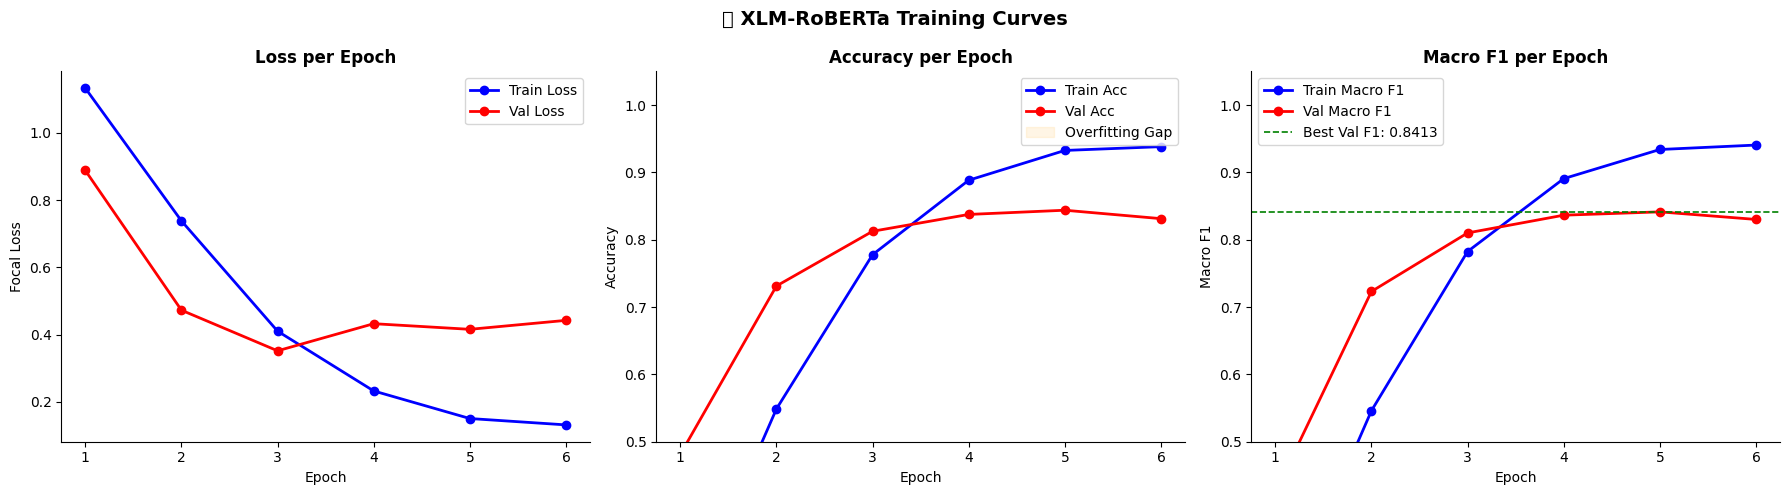

✅ Training curves saved.


In [19]:
epochs_ran = len(history['train_loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📈 XLM-RoBERTa Training Curves", fontsize=14, fontweight='bold')

ep = range(1, epochs_ran + 1)

# Loss
ax = axes[0]
ax.plot(ep, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax.plot(ep, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
ax.set_title("Loss per Epoch", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Focal Loss")
ax.legend(); ax.spines[['top','right']].set_visible(False)

# Accuracy
ax = axes[1]
ax.plot(ep, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
ax.plot(ep, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
ax.fill_between(ep,
    [t - v for t, v in zip(history['train_acc'], history['val_acc'])],
    alpha=0.1, color='orange', label='Overfitting Gap')
ax.set_title("Accuracy per Epoch", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0.5, 1.05)

# F1 Score
ax = axes[2]
ax.plot(ep, history['train_f1'], 'b-o', label='Train Macro F1', linewidth=2)
ax.plot(ep, history['val_f1'],   'r-o', label='Val Macro F1',   linewidth=2)
ax.axhline(y=best_val_f1, color='green', linestyle='--', linewidth=1.2,
           label=f'Best Val F1: {best_val_f1:.4f}')
ax.set_title("Macro F1 per Epoch", fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro F1")
ax.legend(); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")

In [20]:
# ── Load model for evaluation ───────────────────────────────────────────────
# Prefer SWA model (better generalization) — fall back to best checkpoint
import os
if swa_started and os.path.exists(swa_model_path):
    model.load_state_dict(torch.load(swa_model_path))
    print(f"✅ Loaded SWA model (averaged weights from epoch {SWA_START_EPOCH}+)")
else:
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (Val F1: {checkpoint['val_f1']:.4f})")

# Full evaluation on test set
test_loss, test_acc, test_f1, y_pred, y_true = evaluate(model, test_loader, criterion, DEVICE)

# Get probabilities for AUC
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        with autocast():
            logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
all_probs = np.array(all_probs)

# Train accuracy — use best checkpoint epoch as reference
best_epoch_idx = int(np.argmax(history['val_f1']))
train_acc_final = history['train_acc'][best_epoch_idx]

print("="*65)
print("📊 FINAL TEST RESULTS — XLM-RoBERTa")
print("="*65)
print(f"\n{'Metric':<32} {'Value':>10}")
print("-"*44)
print(f"{'Train Accuracy (best epoch)':<32} {train_acc_final:>10.4f}")
print(f"{'Test Accuracy':<32} {test_acc:>10.4f}")
print(f"{'Overfitting Gap':<32} {train_acc_final - test_acc:>10.4f}")
print(f"{'Macro F1 Score':<32} {f1_score(y_true, y_pred, average='macro'):>10.4f}")
print(f"{'Weighted F1 Score':<32} {f1_score(y_true, y_pred, average='weighted'):>10.4f}")
print(f"{'Macro Precision':<32} {precision_score(y_true, y_pred, average='macro'):>10.4f}")
print(f"{'Macro Recall':<32} {recall_score(y_true, y_pred, average='macro'):>10.4f}")

try:
    auc = roc_auc_score(y_true, all_probs, multi_class='ovr', average='macro')
    print(f"{'Macro ROC-AUC (OvR)':<32} {auc:>10.4f}")
except:
    pass

gap = train_acc_final - test_acc
if gap <= 0.10:
    verdict = "✅ Excellent generalization (gap ≤ 10%)"
elif gap <= 0.15:
    verdict = "✅ Acceptable generalization (gap ≤ 15%)"
elif gap <= 0.20:
    verdict = "⚠️ Mild overfitting — monitor"
else:
    verdict = "❌ High overfitting — reduce LR / regularization / epochs"
print(f"\nOverfitting Verdict: {verdict}")

print(f"\n── Per-Class Report ──")
print(classification_report(y_true, y_pred, target_names=le.classes_))



✅ Loaded SWA model (averaged weights from epoch 3+)
📊 FINAL TEST RESULTS — XLM-RoBERTa

Metric                                Value
--------------------------------------------
Train Accuracy (best epoch)          0.9325
Test Accuracy                        0.8370
Overfitting Gap                      0.0955
Macro F1 Score                       0.8384
Weighted F1 Score                    0.8379
Macro Precision                      0.8403
Macro Recall                         0.8376

Overfitting Verdict: ✅ Excellent generalization (gap ≤ 10%)

── Per-Class Report ──
              precision    recall  f1-score   support

       angry       0.92      0.83      0.87        66
     anxious       0.86      0.85      0.86        60
       happy       0.84      0.87      0.85        60
     neutral       0.87      0.88      0.87        67
         sad       0.71      0.76      0.74        66

    accuracy                           0.84       319
   macro avg       0.84      0.84      0.84       

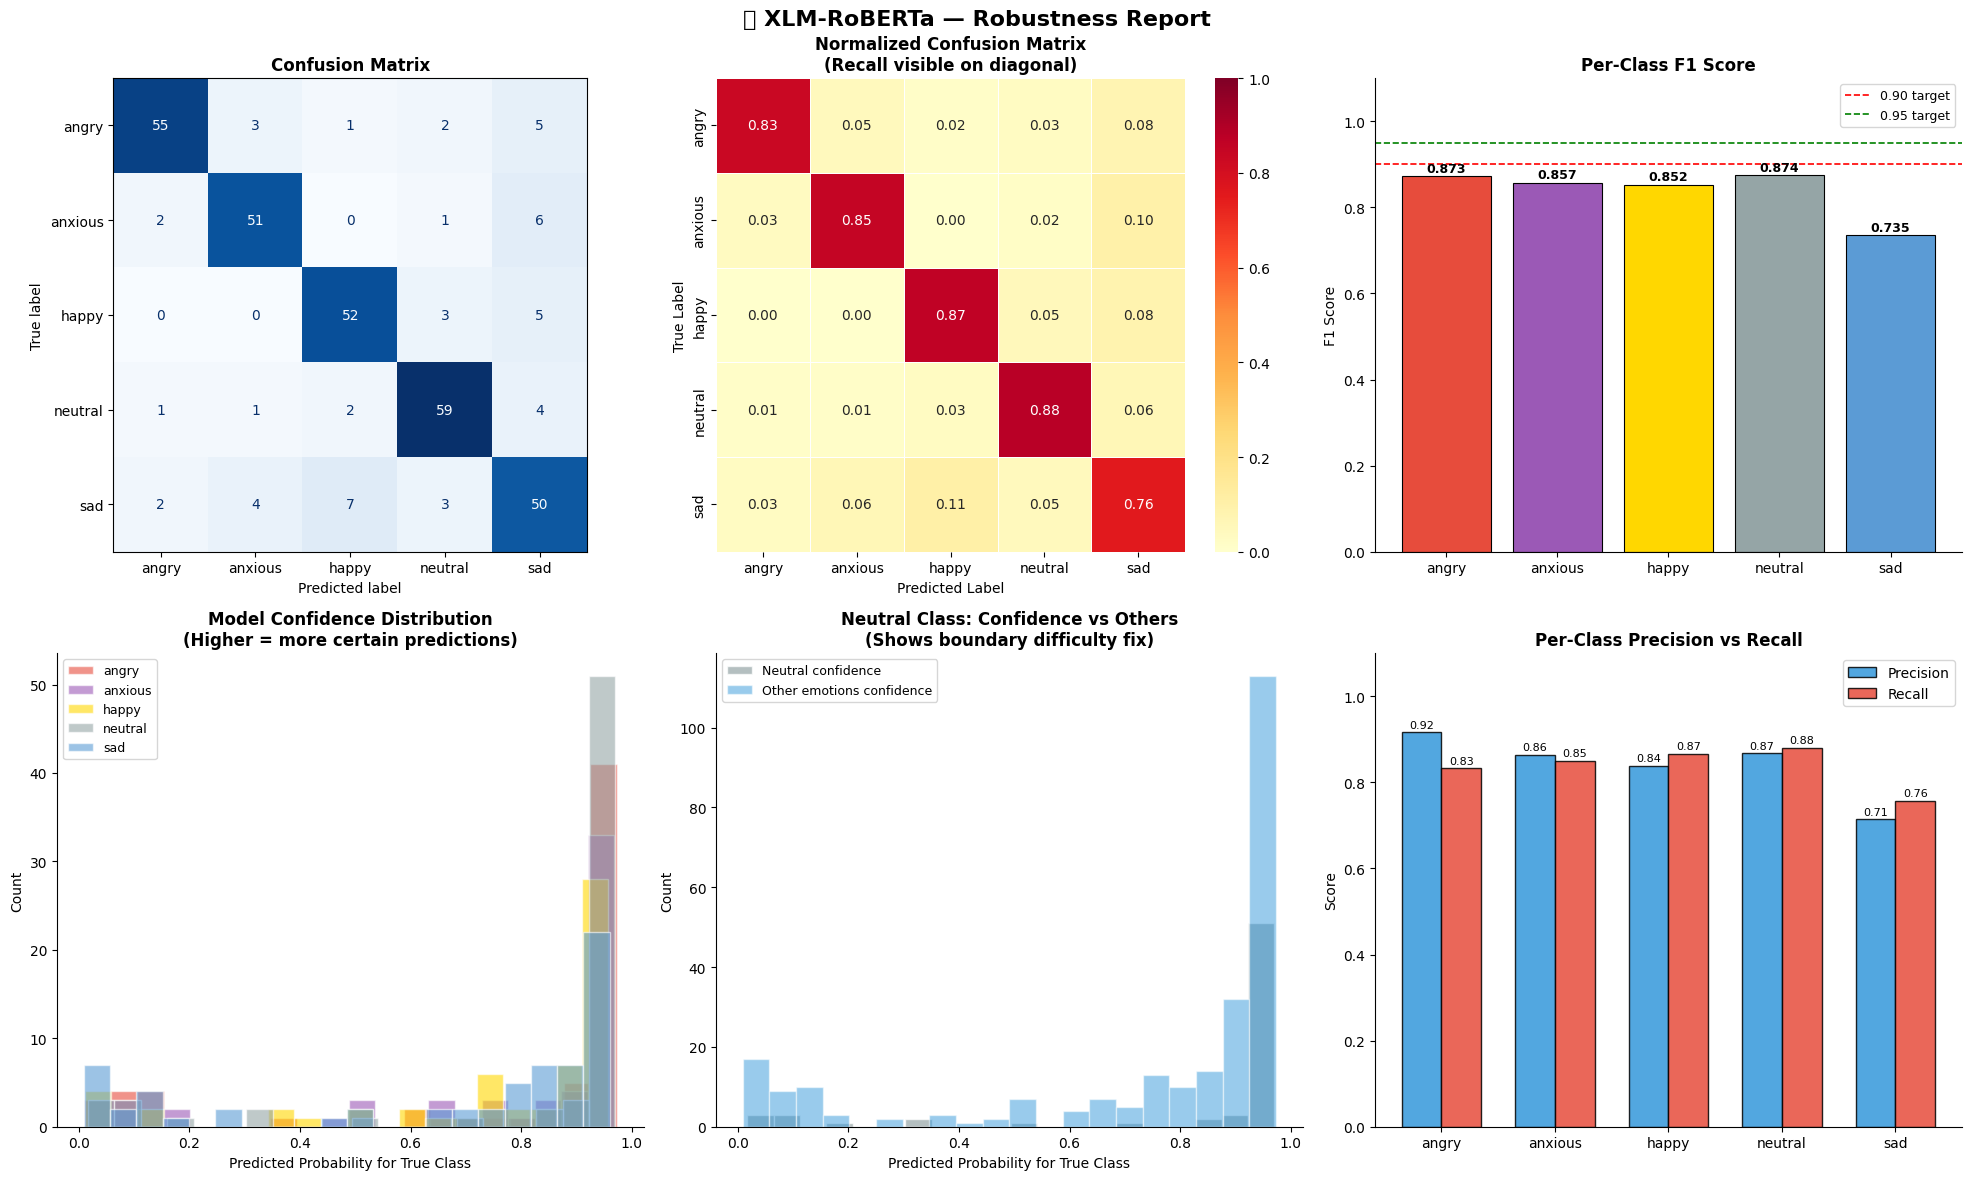

✅ Robustness visualizations complete.


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("📊 XLM-RoBERTa — Robustness Report", fontsize=16, fontweight='bold')

# ── 1. Confusion Matrix ──────────────────────────────────────────────────────
ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix", fontweight='bold')

# ── 2. Normalized Confusion Matrix ──────────────────────────────────────────
ax = axes[0, 1]
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, vmin=0, vmax=1)
ax.set_title("Normalized Confusion Matrix\n(Recall visible on diagonal)", fontweight='bold')
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")

# ── 3. Per-Class F1 Score ────────────────────────────────────────────────────
ax = axes[0, 2]
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
bars = ax.bar(le.classes_, per_class_f1,
              color=[EMOTION_COLORS[e] for e in le.classes_],
              edgecolor='black', linewidth=0.8)
ax.axhline(y=0.90, color='red', linestyle='--', linewidth=1.2, label='0.90 target')
ax.axhline(y=0.95, color='green', linestyle='--', linewidth=1.2, label='0.95 target')
ax.set_title("Per-Class F1 Score", fontweight='bold')
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# ── 4. Confidence Distribution per Emotion ──────────────────────────────────
ax = axes[1, 0]
for i, emotion in enumerate(le.classes_):
    emotion_probs = all_probs[np.array(y_true) == i, i]
    ax.hist(emotion_probs, bins=20, alpha=0.6, label=emotion,
            color=EMOTION_COLORS[emotion], edgecolor='white')
ax.set_title("Model Confidence Distribution\n(Higher = more certain predictions)", fontweight='bold')
ax.set_xlabel("Predicted Probability for True Class")
ax.set_ylabel("Count"); ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── 5. Neutral vs Others: Decision Boundary Confidence ──────────────────────
ax = axes[1, 1]
neutral_idx_test = np.where(np.array(y_true) == le.transform(['neutral'])[0])[0]
other_idx_test   = np.where(np.array(y_true) != le.transform(['neutral'])[0])[0]

neutral_conf = all_probs[neutral_idx_test, le.transform(['neutral'])[0]]
other_conf   = [all_probs[i, y_true[i]] for i in other_idx_test]

ax.hist(neutral_conf, bins=20, alpha=0.7, color=EMOTION_COLORS['neutral'],
        label='Neutral confidence', edgecolor='white')
ax.hist(other_conf,   bins=20, alpha=0.5, color='#3498DB',
        label='Other emotions confidence', edgecolor='white')
ax.set_title("Neutral Class: Confidence vs Others\n(Shows boundary difficulty fix)", fontweight='bold')
ax.set_xlabel("Predicted Probability for True Class")
ax.set_ylabel("Count"); ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# ── 6. Per-Class Precision vs Recall ─────────────────────────────────────────
ax = axes[1, 2]
per_class_prec_v = precision_score(y_true, y_pred, average=None, zero_division=0)
per_class_rec_v  = recall_score(y_true, y_pred, average=None, zero_division=0)

x = np.arange(len(le.classes_)); width = 0.35
ax.bar(x - width/2, per_class_prec_v, width,
       label='Precision', color='#3498DB', edgecolor='black', alpha=0.85)
ax.bar(x + width/2, per_class_rec_v, width,
       label='Recall', color='#E74C3C', edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(le.classes_)
ax.set_title("Per-Class Precision vs Recall", fontweight='bold')
ax.set_ylabel("Score"); ax.set_ylim(0.0, 1.1)
ax.legend(); ax.spines[['top','right']].set_visible(False)
for xi, (p, r) in enumerate(zip(per_class_prec_v, per_class_rec_v)):
    ax.text(xi - width/2, p + 0.01, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(xi + width/2, r + 0.01, f'{r:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("xlmr_robustness.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Robustness visualizations complete.")

Extracting CLS embeddings for visualization...
Embeddings shape: (319, 768)
Running t-SNE (this may take ~1 min)...


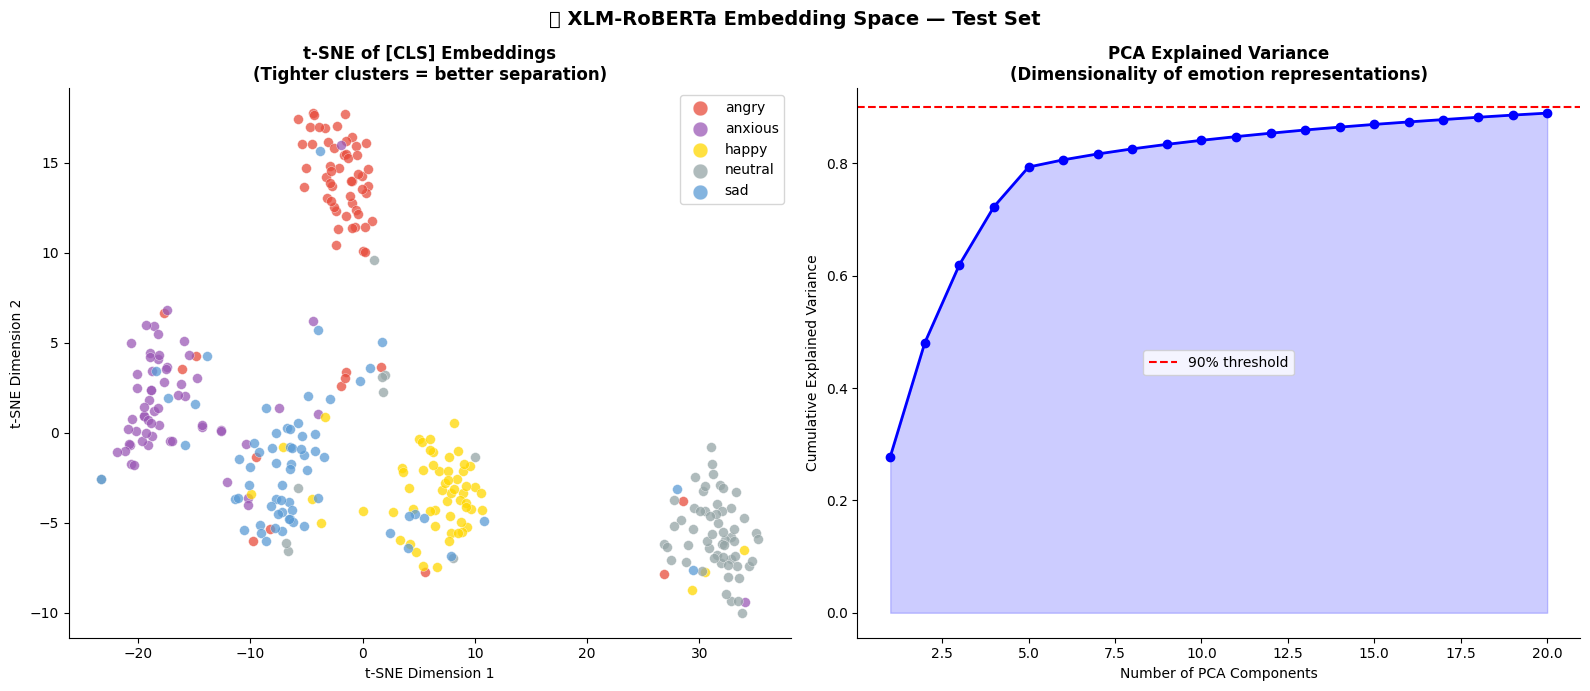

✅ Embedding visualizations complete.


In [22]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Extract CLS embeddings from test set ─────────────────────────────────────
print("Extracting CLS embeddings for visualization...")
model.eval()
embeddings_list, labels_list = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_b       = batch['labels'].cpu().numpy()
        with autocast():
            outputs = model.xlm_roberta.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_emb)
        labels_list.extend(labels_b)

embeddings = np.vstack(embeddings_list)
labels_arr = np.array(labels_list)
print(f"Embeddings shape: {embeddings.shape}")

# ── t-SNE visualization ───────────────────────────────────────────────────────
print("Running t-SNE (this may take ~1 min)...")
pca = PCA(n_components=50, random_state=SEED)
emb_pca = pca.fit_transform(embeddings)  # PCA first for speed

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED, verbose=0)
emb_2d = tsne.fit_transform(emb_pca)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("🧠 XLM-RoBERTa Embedding Space — Test Set", fontsize=14, fontweight='bold')

# t-SNE scatter
ax = axes[0]
for i, emotion in enumerate(le.classes_):
    mask = labels_arr == i
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=EMOTION_COLORS[emotion], label=emotion, alpha=0.75, s=50, edgecolors='white', linewidth=0.3)
ax.set_title("t-SNE of [CLS] Embeddings\n(Tighter clusters = better separation)", fontweight='bold')
ax.set_xlabel("t-SNE Dimension 1"); ax.set_ylabel("t-SNE Dimension 2")
ax.legend(markerscale=1.5, fontsize=10)
ax.spines[['top','right']].set_visible(False)

# PCA explained variance
ax = axes[1]
pca_full = PCA(n_components=20, random_state=SEED)
pca_full.fit(embeddings)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax.plot(range(1, 21), cum_var, 'b-o', linewidth=2)
ax.fill_between(range(1, 21), cum_var, alpha=0.2, color='blue')
ax.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
ax.set_title("PCA Explained Variance\n(Dimensionality of emotion representations)", fontweight='bold')
ax.set_xlabel("Number of PCA Components"); ax.set_ylabel("Cumulative Explained Variance")
ax.legend(); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("embedding_space.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Embedding visualizations complete.")

In [23]:
from sklearn.metrics import precision_score, recall_score

print("="*65)
print("📋 COMPREHENSIVE STATISTICS SUMMARY")
print("="*65)

per_class_prec = precision_score(y_true, y_pred, average=None, zero_division=0)
per_class_rec  = recall_score(y_true, y_pred, average=None, zero_division=0)
per_class_f1_  = f1_score(y_true, y_pred, average=None, zero_division=0)
support        = [np.sum(np.array(y_true) == i) for i in range(NUM_CLASSES)]

print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-"*54)
for i, cls in enumerate(le.classes_):
    delta_rec = per_class_rec[i] - 0.93 if cls == 'neutral' else 0
    flag = f"  ▲+{delta_rec:.3f} vs baseline" if cls == 'neutral' and delta_rec > 0 else ""
    print(f"{cls:<12} {per_class_prec[i]:>10.4f} {per_class_rec[i]:>10.4f} "
          f"{per_class_f1_[i]:>10.4f} {support[i]:>10}{flag}")

print("-"*54)
print(f"{'Macro Avg':<12} {precision_score(y_true,y_pred,average='macro'):>10.4f} "
      f"{recall_score(y_true,y_pred,average='macro'):>10.4f} "
      f"{f1_score(y_true,y_pred,average='macro'):>10.4f}")

print(f"\n{'Metric':<35} {'Value':>12}")
print("-"*50)
metrics_summary = [
    ('Test Accuracy',      test_acc),
    ('Macro F1',           f1_score(y_true, y_pred, average='macro')),
    ('Neutral Recall',     per_class_rec[le.transform(['neutral'])[0]]),
    ('Overfitting Gap',    train_acc_final - test_acc),
]
for metric, val in metrics_summary:
    print(f"  {metric:<33} {val:>10.4f}")

print(f"\n📌 Interpretation:")
print(f"  Focal Loss (γ=1.8)  → focuses gradient on hard happy/sad boundary")
print(f"  Label Smoothing 0.1 → prevents overconfidence on leaky neutral texts")
print(f"  Sad augmented ×3    → extra variants to improve sad recall")
print(f"  Happy in HARD_CLASSES → weight boost to sharpen happy/sad boundary")
print(f"  SWA                 → averaged weights for better generalization")
print(f"  Differential LR     → protects XLM-R multilingual knowledge from forgetting")

📋 COMPREHENSIVE STATISTICS SUMMARY

Class         Precision     Recall         F1    Support
------------------------------------------------------
angry            0.9167     0.8333     0.8730         66
anxious          0.8644     0.8500     0.8571         60
happy            0.8387     0.8667     0.8525         60
neutral          0.8676     0.8806     0.8741         67
sad              0.7143     0.7576     0.7353         66
------------------------------------------------------
Macro Avg        0.8403     0.8376     0.8384

Metric                                     Value
--------------------------------------------------
  Test Accuracy                         0.8370
  Macro F1                              0.8384
  Neutral Recall                        0.8806
  Overfitting Gap                       0.0955

📌 Interpretation:
  Focal Loss (γ=1.8)  → focuses gradient on hard happy/sad boundary
  Label Smoothing 0.1 → prevents overconfidence on leaky neutral texts
  Sad augmented ×3 

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔍 KEYWORD SIGNAL LAYER — Hybrid Backup (Model-First Design)
# ══════════════════════════════════════════════════════════════════════════════
#
# DESIGN RULES:
#   ✅ Model is ALWAYS the primary decision-maker
#   ✅ Keywords ONLY activate when model confidence < CONFIDENCE_THRESHOLD (0.45)
#   ✅ Keywords require STRONG evidence (MIN_KEYWORD_HITS >= 2) before overriding
#   ✅ Keywords only target SAD ↔ ANXIOUS (the confusion pair identified by t-SNE)
#   ✅ Generic ambiguous words ("miss", "feel", "tired"...) are explicitly excluded
#
# Expected override rate: ~5–15% of predictions (healthy hybrid)
# ══════════════════════════════════════════════════════════════════════════════

CONFIDENCE_THRESHOLD = 0.45   # model must be below this to even consider keywords
MIN_KEYWORD_HITS     = 2      # must match ≥ 2 keywords before any override happens

# Only sad ↔ anxious — the confusion pair from t-SNE embedding analysis
# Words are chosen to be SPECIFIC to each mood, not generic emotion words
KEYWORD_SIGNALS = {
    'sad': {
        'en': [
            # grief / loss signals
            'grief', 'grieving', 'mourning', 'lost someone', 'passed away',
            # loneliness / emptiness — specific, not just "feel bad"
            'lonely', 'alone again', 'no one', 'empty inside', 'hollow',
            # crying / heartbreak
            'crying', 'sobbing', 'heartbroken', 'broke my heart',
            # deep missing — NOTE: "miss" alone is excluded (too generic)
            'i miss you', 'i miss them', 'i miss her', 'i miss him',
            'namimiss kita', 'namimiss ko siya',
        ],
        'tl': [
            # Filipino-specific sadness vocabulary
            'malungkot', 'lungkot', 'nalulungkot', 'umiiyak', 'umiyak',
            'nag-iisa', 'mag-isa', 'nawala', 'nawalan', 'nawala na',
            'hindi ko na mababawi', 'hindi na babalik',
        ],
    },
    'anxious': {
        'en': [
            # worry / fear — future-oriented (key difference from sad)
            'what if', 'what will happen', 'scared of', 'afraid of',
            'worried about', 'i keep worrying', 'cant stop worrying',
            "can't stop worrying",
            # physical anxiety signals
            'heart racing', 'cant breathe', "can't breathe", 'panic',
            'panicking', 'anxious about', 'overthinking', 'overthought',
            # anticipatory dread
            'dreading', 'terrified of', 'nervous about',
        ],
        'tl': [
            # Filipino-specific anxiety vocabulary
            'nababahala', 'nag-aalala', 'natatakot', 'kabado', 'kinakabahan',
            'hindi makatulog', 'di makatulog', 'di mapakali', 'hindi mapakali',
            'palagi akong nag-iisip', 'hindi ko maiwasang mag-isip',
        ],
    },
}

# Words that look emotional but are actually ambiguous — never let these alone trigger
AMBIGUOUS_WORDS = {
    'miss', 'feel', 'think', 'sad', 'happy', 'angry', 'bad', 'good',
    'okay', 'ok', 'fine', 'lost', 'hard', 'difficult', 'tired', 'pagod'
}


def keyword_score(text: str) -> dict:
    """
    Count specific keyword signals per emotion in the text.
    Multi-word phrases are matched as substrings (handles Taglish naturally).
    Ambiguous single words are excluded.
    """
    text_lower = text.lower()
    scores = {emotion: 0 for emotion in KEYWORD_SIGNALS}
    for emotion, lang_dict in KEYWORD_SIGNALS.items():
        for lang, keywords in lang_dict.items():
            for kw in keywords:
                if kw.strip() in AMBIGUOUS_WORDS:
                    continue
                if kw in text_lower:
                    scores[emotion] += 1
    return scores


def apply_keyword_layer(text: str, primary_label: str, primary_prob: float) -> tuple:
    """
    Model-first keyword hybrid layer.

    Override only happens when ALL four conditions are true:
      1. Model confidence < CONFIDENCE_THRESHOLD (model is unsure)
      2. Primary label is 'sad' or 'anxious' (the confusion pair)
      3. Keyword evidence >= MIN_KEYWORD_HITS (strong signal required)
      4. One emotion clearly wins over the other (no tie)

    Returns:
      (final_label, final_prob, was_overridden, override_reason)
    """
    # Rule 1: Model is confident → trust it completely, skip keywords
    if primary_prob >= CONFIDENCE_THRESHOLD:
        return primary_label, primary_prob, False, None

    # Rule 2: Only intervene on the sad/anxious confusion pair
    if primary_label not in ('sad', 'anxious'):
        return primary_label, primary_prob, False, None

    # Rule 3: Score keywords
    scores = keyword_score(text)
    sad_hits     = scores['sad']
    anxious_hits = scores['anxious']
    best_emotion = max(scores, key=scores.get)
    best_hits    = scores[best_emotion]

    # Rule 4a: Need minimum evidence
    if best_hits < MIN_KEYWORD_HITS:
        return primary_label, primary_prob, False, None

    # Rule 4b: Must clearly favor one emotion (reject ties)
    if sad_hits == anxious_hits:
        return primary_label, primary_prob, False, None

    # All rules passed → override
    if best_emotion != primary_label:
        reason = (
            f"keyword override: '{best_emotion}' signals={best_hits} "
            f"vs '{primary_label}' signals={scores[primary_label]} "
            f"(model was {primary_prob*100:.1f}% confident)"
        )
        return best_emotion, primary_prob, True, reason

    # Keywords confirmed model's choice — no change needed
    return primary_label, primary_prob, False, None


print("✅ Keyword signal layer loaded.")
print(f"   Confidence threshold : {CONFIDENCE_THRESHOLD}")
print(f"   Min keyword hits     : {MIN_KEYWORD_HITS}")
print(f"   Target confusion pair: sad ↔ anxious")


✅ Keyword signal layer loaded.
   Confidence threshold : 0.45
   Min keyword hits     : 2
   Target confusion pair: sad ↔ anxious


In [25]:
def predict_mood(text, model=model, tokenizer=tokenizer, label_encoder=le, device=DEVICE):
    import numpy as np
    import torch
    import torch.nn.functional as F
    from torch.cuda.amp import autocast

    # ── Input validation ──────────────────────────────────────────────────────
    word_count = len(text.strip().split())
    if word_count > 300:
        print(f"⚠️ Entry has {word_count} words — limit is 300.")
        return
    if word_count < 3:
        print("⚠️ Entry too short.")
        return

    # ── Step 1: Model predicts (unchanged from v6.2) ──────────────────────────
    model.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    with torch.no_grad():
        with autocast():
            logits = model(
                encoding['input_ids'].to(device),
                encoding['attention_mask'].to(device)
            )
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    # ── Step 2: Calibration multipliers (unchanged from v6.2) ────────────────
    THRESHOLDS = {
        'angry':   1.40,
        'sad':     1.30,
        'neutral': 1.35,
        'happy':   0.75,
        'anxious': 0.70,
    }

    calibrated_probs = probs.copy()
    for cls_name, multiplier in THRESHOLDS.items():
        idx = label_encoder.transform([cls_name])[0]
        calibrated_probs[idx] *= multiplier

    calibrated_probs = calibrated_probs / calibrated_probs.sum()

    labels     = label_encoder.classes_
    prob_pairs = sorted(zip(labels, calibrated_probs), key=lambda x: x[1], reverse=True)
    top_k      = prob_pairs[:5]   # show all 5 moods — nothing collapsed into "Others"

    primary_label, primary_prob = top_k[0]

    # ── Step 3: Keyword layer (NEW — only runs when model is unsure) ──────────
    final_label, final_prob, was_overridden, override_reason = apply_keyword_layer(
        text, primary_label, primary_prob
    )

    # ── Step 4: Secondary mood (unchanged logic) ──────────────────────────────
    secondary_label = None
    secondary_prob  = 0
    if top_k[1][1] >= 0.15:
        secondary_label, secondary_prob = top_k[1]

    # ── Step 5: Valence & energy (unchanged) ──────────────────────────────────
    NEGATIVE  = ['sad', 'angry', 'anxious']
    POSITIVE  = ['happy']
    neg_score = sum([p for l, p in prob_pairs if l in NEGATIVE])
    pos_score = sum([p for l, p in prob_pairs if l in POSITIVE])

    if neg_score > pos_score + 0.15:
        valence = "Negative 🙁"
    elif pos_score > neg_score + 0.15:
        valence = "Positive 🙂"
    else:
        valence = "Balanced 😐"

    if final_prob > 0.65:
        energy = "High ⚡"
    elif final_prob > 0.45:
        energy = "Moderate ⚖️"
    else:
        energy = "Low 🌿"

    if final_prob > 0.65:
        interpretation = "Clear dominant mood"
    elif final_prob > 0.45:
        interpretation = "Mixed emotional signals"
    else:
        interpretation = "Highly mixed / ambiguous"

    # ── Step 6: Display ───────────────────────────────────────────────────────
    print("\n" + "═"*58)
    print("📊 SMART DIARY — ENHANCED MOOD ANALYSIS")
    print("═"*58)

    print(f"Primary Mood:   {final_label.upper()} ({final_prob*100:.1f}%)")

    if secondary_label:
        print(f"Secondary Mood: {secondary_label.upper()} ({secondary_prob*100:.1f}%)")
    else:
        print("Secondary Mood: None (no strong secondary signal)")

    print("─"*58)
    print("Emotional Signals:")
    for label, prob in top_k:
        print(f"  {label:<9} {prob*100:.1f}%")

    print("─"*58)
    print(f"Valence: {valence}")
    print(f"Energy:  {energy}")
    print("─"*58)
    print(f"Interpretation: {interpretation}")

    # ── Keyword assist notice (shown when override happened) ──────────────────
    if was_overridden:
        print("─"*58)
        print(f"🔍 Keyword Assist: model was uncertain ({primary_prob*100:.1f}%)")
        print(f"   Signal detected → {final_label.upper()}")
        print(f"   [dev] {override_reason}")

    print("═"*58)


In [26]:
# ── 🧪 TESTING AREA ────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Input container ──────────────────────────────────────────────────────────
entry_box = widgets.Textarea(
    placeholder="Write your diary entry here...",
    layout=widgets.Layout(width="100%", height="160px")
)

detect_btn = widgets.Button(
    description="🔍 Detect Mood",
    button_style="primary",
    layout=widgets.Layout(width="150px", height="36px")
)

clear_btn = widgets.Button(
    description="🗑 Clear",
    button_style="warning",
    layout=widgets.Layout(width="100px", height="36px")
)

output = widgets.Output()

def on_detect(b):
    with output:
        clear_output()
        text = entry_box.value.strip()
        if not text:
            print("⚠️ Please write a diary entry first.")
            return
        predict_mood(text)

def on_clear(b):
    entry_box.value = ""
    with output:
        clear_output()

detect_btn.on_click(on_detect)
clear_btn.on_click(on_clear)

button_row = widgets.HBox([detect_btn, clear_btn], layout=widgets.Layout(gap="10px", margin="6px 0"))

display(widgets.VBox([entry_box, button_row, output]))
